In [1]:
import os
import zipfile
import random
from shutil import copyfile, rmtree

In [2]:
train_dir = './train'
test_dir = './test'
base_dir = './Multi-class Weather Dataset'

In [7]:
categories = ['Cloudy', 'Rain','Shine','Sunrise']

In [4]:
if os.path.exists(train_dir):
    rmtree(train_dir)       #폴더가 있으면 지워짐.
if os.path.exists(test_dir):
    rmtree(test_dir)

In [5]:
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


In [8]:
for category in categories:
    os.makedirs(os.path.join(train_dir, category), exist_ok=True)
    os.makedirs(os.path.join(test_dir, category), exist_ok=True)

    category_path = os.path.join(base_dir, category)
    images = os.listdir(category_path)
    random.shuffle(images)

    split_index = int(0.8 * len(images))
    train_images = images[:split_index]
    test_images = images[split_index:]

    for image in train_images:
        src = os.path.join(category_path, image)
        dst = os.path.join(train_dir, category, image)
        copyfile(src, dst)

    for image in test_images:
        src = os.path.join(category_path, image)
        dst = os.path.join(test_dir, category, image)
        copyfile(src, dst)

In [9]:
import torch
import time
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torchvision.datasets as datasets
from torchvision.utils import make_grid
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt
import matplotlib.image as image
import numpy as np

In [10]:
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
		    mean = [0.5, 0.5, 0.5], 
		    std = [0.5, 0.5, 0.5]
    )
])

In [12]:
transform_test = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
		    mean = [0.5, 0.5, 0.5], 
		    std = [0.5, 0.5, 0.5]
    )
])

In [13]:
train_dataset = datasets.ImageFolder(
    root= 'train/',
    transform=transform_train
)

In [14]:
dataset_size = len(train_dataset)
train_size = int(0.8 * dataset_size)
val_size = dataset_size - train_size

In [16]:
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

ValueError: Sum of input lengths does not equal the length of the input dataset!

In [ ]:
val_dataset

# <torch.utils.data.dataset.Subset at 0x1cdf0bd6f20>

In [18]:
test_dataset = datasets.ImageFolder(
    root= 'test/',
    transform=transform_test
)

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [29]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 60
plt.rcParams.update({'font.size': 20})
def imshow(input):
    input = input.numpy().transpose((1, 2, 0))
    mean = np.array([0.5, 0.5, 0.5])
    std = np.array([0.5, 0.5, 0.5])
    input = std * input + mean
    input = np.clip(input, 0, 1)
    plt.imshow(input)
    plt.show()

In [30]:
class_names = {
    0: 'Cloudy',
    1: 'Rain',
    2: 'Shine',
    3: 'Sunrise'
}

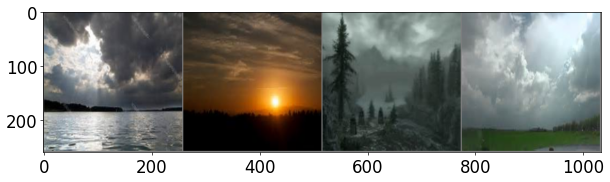

In [31]:
iterator = iter(train_dataloader)
images, labels = next(iterator)
out = make_grid(images[:4])
imshow(out)

In [ ]:
print([class_names[labels[i].item()]for i in range(4)])

# ['Cloudy', 'Sunrise', 'Cloudy', 'Cloudy']

['Cloudy', 'Sunrise', 'Cloudy', 'Cloudy']


In [33]:
class Model1(nn.Module):
    def __init__(self): 
        super(Model1, self).__init__()
        self.linear1 = nn.Linear(256*256*3, 4)
        self.flatten = nn.Flatten()

    def forward(self, x):
        x = self.flatten(x)
        x = self.linear1(x)
        return x

In [34]:
def train():
    start_time = time.time()
    print(f'[Epoch {epoch+1}] Training...')
    model.train()
    total = 0
    running_loss = 0.0
    running_correct = 0

    for i, batch in enumerate(train_dataloader):
        imgs, labels = batch
        imgs, labels = imgs.cuda(), labels.cuda()
        outputs = model(imgs)
        optimizer.zero_grad()
        _, preds  = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total += labels.shape[0]   
        running_loss += loss.item()
        running_correct += (preds == labels).sum(preds == labels.data)
        if i % log_step == 0:
            print(f'[Batch: {i + 1}] running train loss: {running_loss / total}, running train accuracy: {running_correct / total}')

    print(f'train loss: {running_loss / total}, accuracy: {running_correct / total}')
    print("elapsed time:", time.time() - start_time)
    return running_loss / total, (running_correct / total).item()

NameError: name 'epoch' is not defined